In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import numpy as np
import pandas as pd
import os
import scanpy as sc
import scvi
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
from rich import print
# from scib_metrics.benchmark import Benchmarker, BatchCorrection, BioConservation
# from harmony import harmonize

# Set SVG font type to 'none' to keep text as text in SVG files
plt.rcParams["svg.fonttype"] = "none"
sc.settings._vector_friendly = True


scvi.settings.seed = 34

SAVE_CSV = True

Seed set to 34


In [3]:
# from nichevi.spatial_analysis import SpatialAnalysis
from params import setup  # , cell_type_color_dict, niche_color_dict, niche_setup

In [4]:
sc.set_figure_params(dpi=150, fontsize=12, format="svg")

figure_dir = setup.FIGURES_FOLDER

plots = True

In [5]:
data_dir, data_file = setup.DATA_FOLDER, setup.DATA_FILE

data_file_name = os.path.splitext(data_file)[0]
print(data_file_name)


# path_to_save = os.path.join("../../niche-VI-experiments/checkpoints", data_file_name)
path_to_save = "/home/nathanl/scviva_paper/merfish_brain/checkpoints/"
os.makedirs(path_to_save, exist_ok=True)

adata_legacy_hvg4k

In [7]:
if SAVE_CSV:
    # Define the save path as a string and create the directory if it doesn't exist
    path_to_save_scib = "/home/nathanl/scviva_paper/crc_visium_hd/figures"
    os.makedirs(path_to_save_scib, exist_ok=True)

In [8]:
if SAVE_CSV:
    df_DE = pd.read_csv(
        path_to_save_scib + "/BioCons_cell_type_adata_legacy_hvg4k.csv", index_col=0
    )


MODEL = "ln_s10_w400_scanvi_lr0.0005_poisson"
df_DE = df_DE.rename(
    columns={
        "X_scanvi": "SCANVI",
        MODEL + "_X_nicheVI": "NICHEVI",
        "simvi25_both_mae_50": "SIMVI",
        "X_banksy_02_harmony": "BANKSY",
        # "X_nicheformer_e5": "NICHEFORMER",
        # "simvi25_interact_mae_50": "SIMVI-INTERACT",
    }
)
df_DE = df_DE.reindex(columns=["SCANVI", "SIMVI", "BANKSY", "NICHEVI"])
df_DE

,SCANVI,SIMVI,BANKSY,NICHEVI
cell_type,,,,
Tumor,0.422716,0.420381,0.432566,0.413336
Stromal (Fibroblast-like),0.378008,0.387277,0.405694,0.398435
Neutrophils / Inflammatory myeloid,0.414513,0.451055,0.503961,0.425631
Plasma B cells,0.406378,0.425829,0.463897,0.428728
Macrophages,0.259962,0.272093,0.319445,0.276614
Myofibroblasts,0.436387,0.444716,0.451117,0.449891
Endothelial cells,0.343492,0.362103,0.409359,0.422286
Plasma B cells / Fibroblast mix,0.386749,0.453458,0.506798,0.432997
Smooth muscle,0.486510,0.472024,0.506591,0.533093


In [20]:
region_mean = df_DE.mean(axis=0)
region_mean

SCANVI     0.392746
SIMVI      0.409882
BANKSY     0.444381
NICHEVI    0.420112
dtype: float64

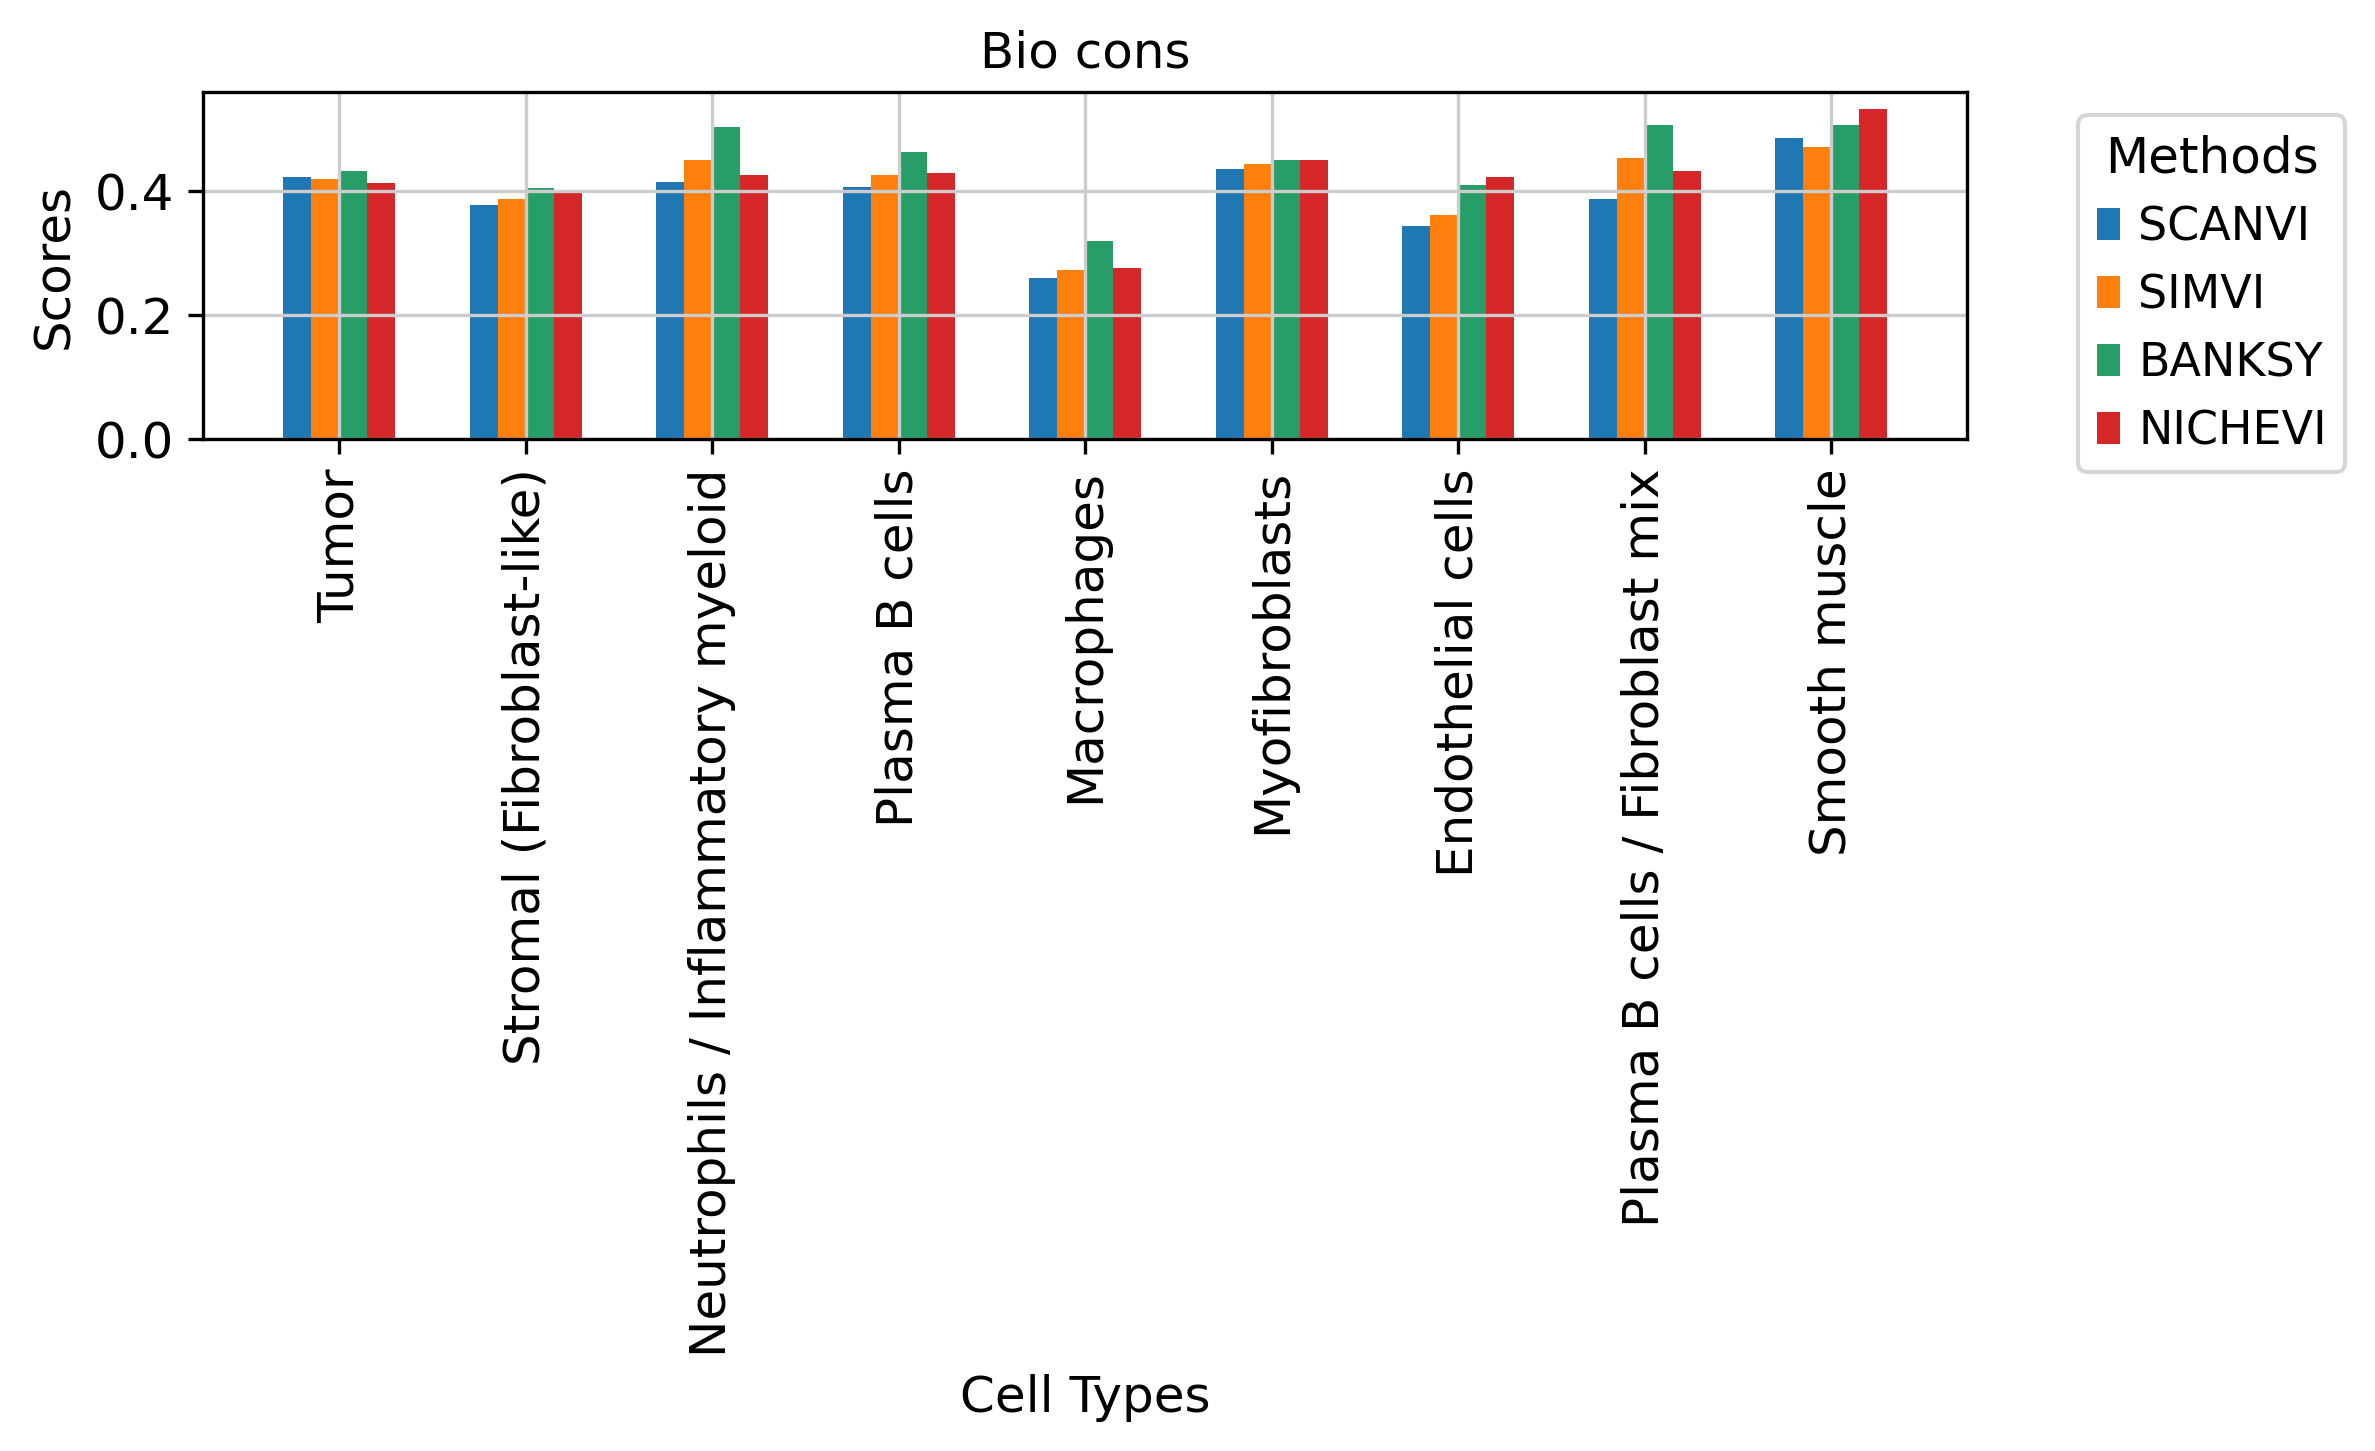

In [21]:
df = df_DE

# Plot settings
fig, ax = plt.subplots(
    figsize=(len(df) * 0.9, 5)  # Width based on number of cell types
)

# Define x locations for each cell type
x = np.arange(len(df.index))

# Set bar width
bar_width = 0.15

# Plot each method score as a separate bar within each cell type
for i, method in enumerate(df.columns):
    ax.bar(x + i * bar_width, df[method], width=bar_width, label=method)

# Add x-ticks and labels
ax.set_xticks(x + bar_width * (len(df.columns) - 1) / 2)
ax.set_xticklabels(df.index, rotation=90)

# Set legend and labels
ax.legend(title="Methods", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_ylabel("Scores")
ax.set_xlabel("Cell Types")

# Show plot
plt.title("Bio cons")
# plt.title('SCIB score')
# plt.title('Batch corr')
plt.tight_layout()
# plt.savefig(f"{setup.FIGURES_FOLDER}/cell_type_scib_batch.png", dpi=1000)
# plt.savefig(f"{setup.FIGURES_FOLDER}/cell_type_scib_batch.svg", dpi=1000)
plt.show()

Common methods: ['SCANVI', 'NICHEVI', 'BANKSY', 'SIMVI']

X-axis (per-cell-type cLISI):

mean     std
SCANVI   0.3927  0.0638
NICHEVI  0.4201  0.0662
BANKSY   0.4469  0.0620
SIMVI    0.4099  0.0621

Y-axis (overall bio conservation):

SCANVI     0.7760
NICHEVI    0.7455
BANKSY     0.6123
SIMVI      0.6450
Name: Bio conservation, dtype: float64

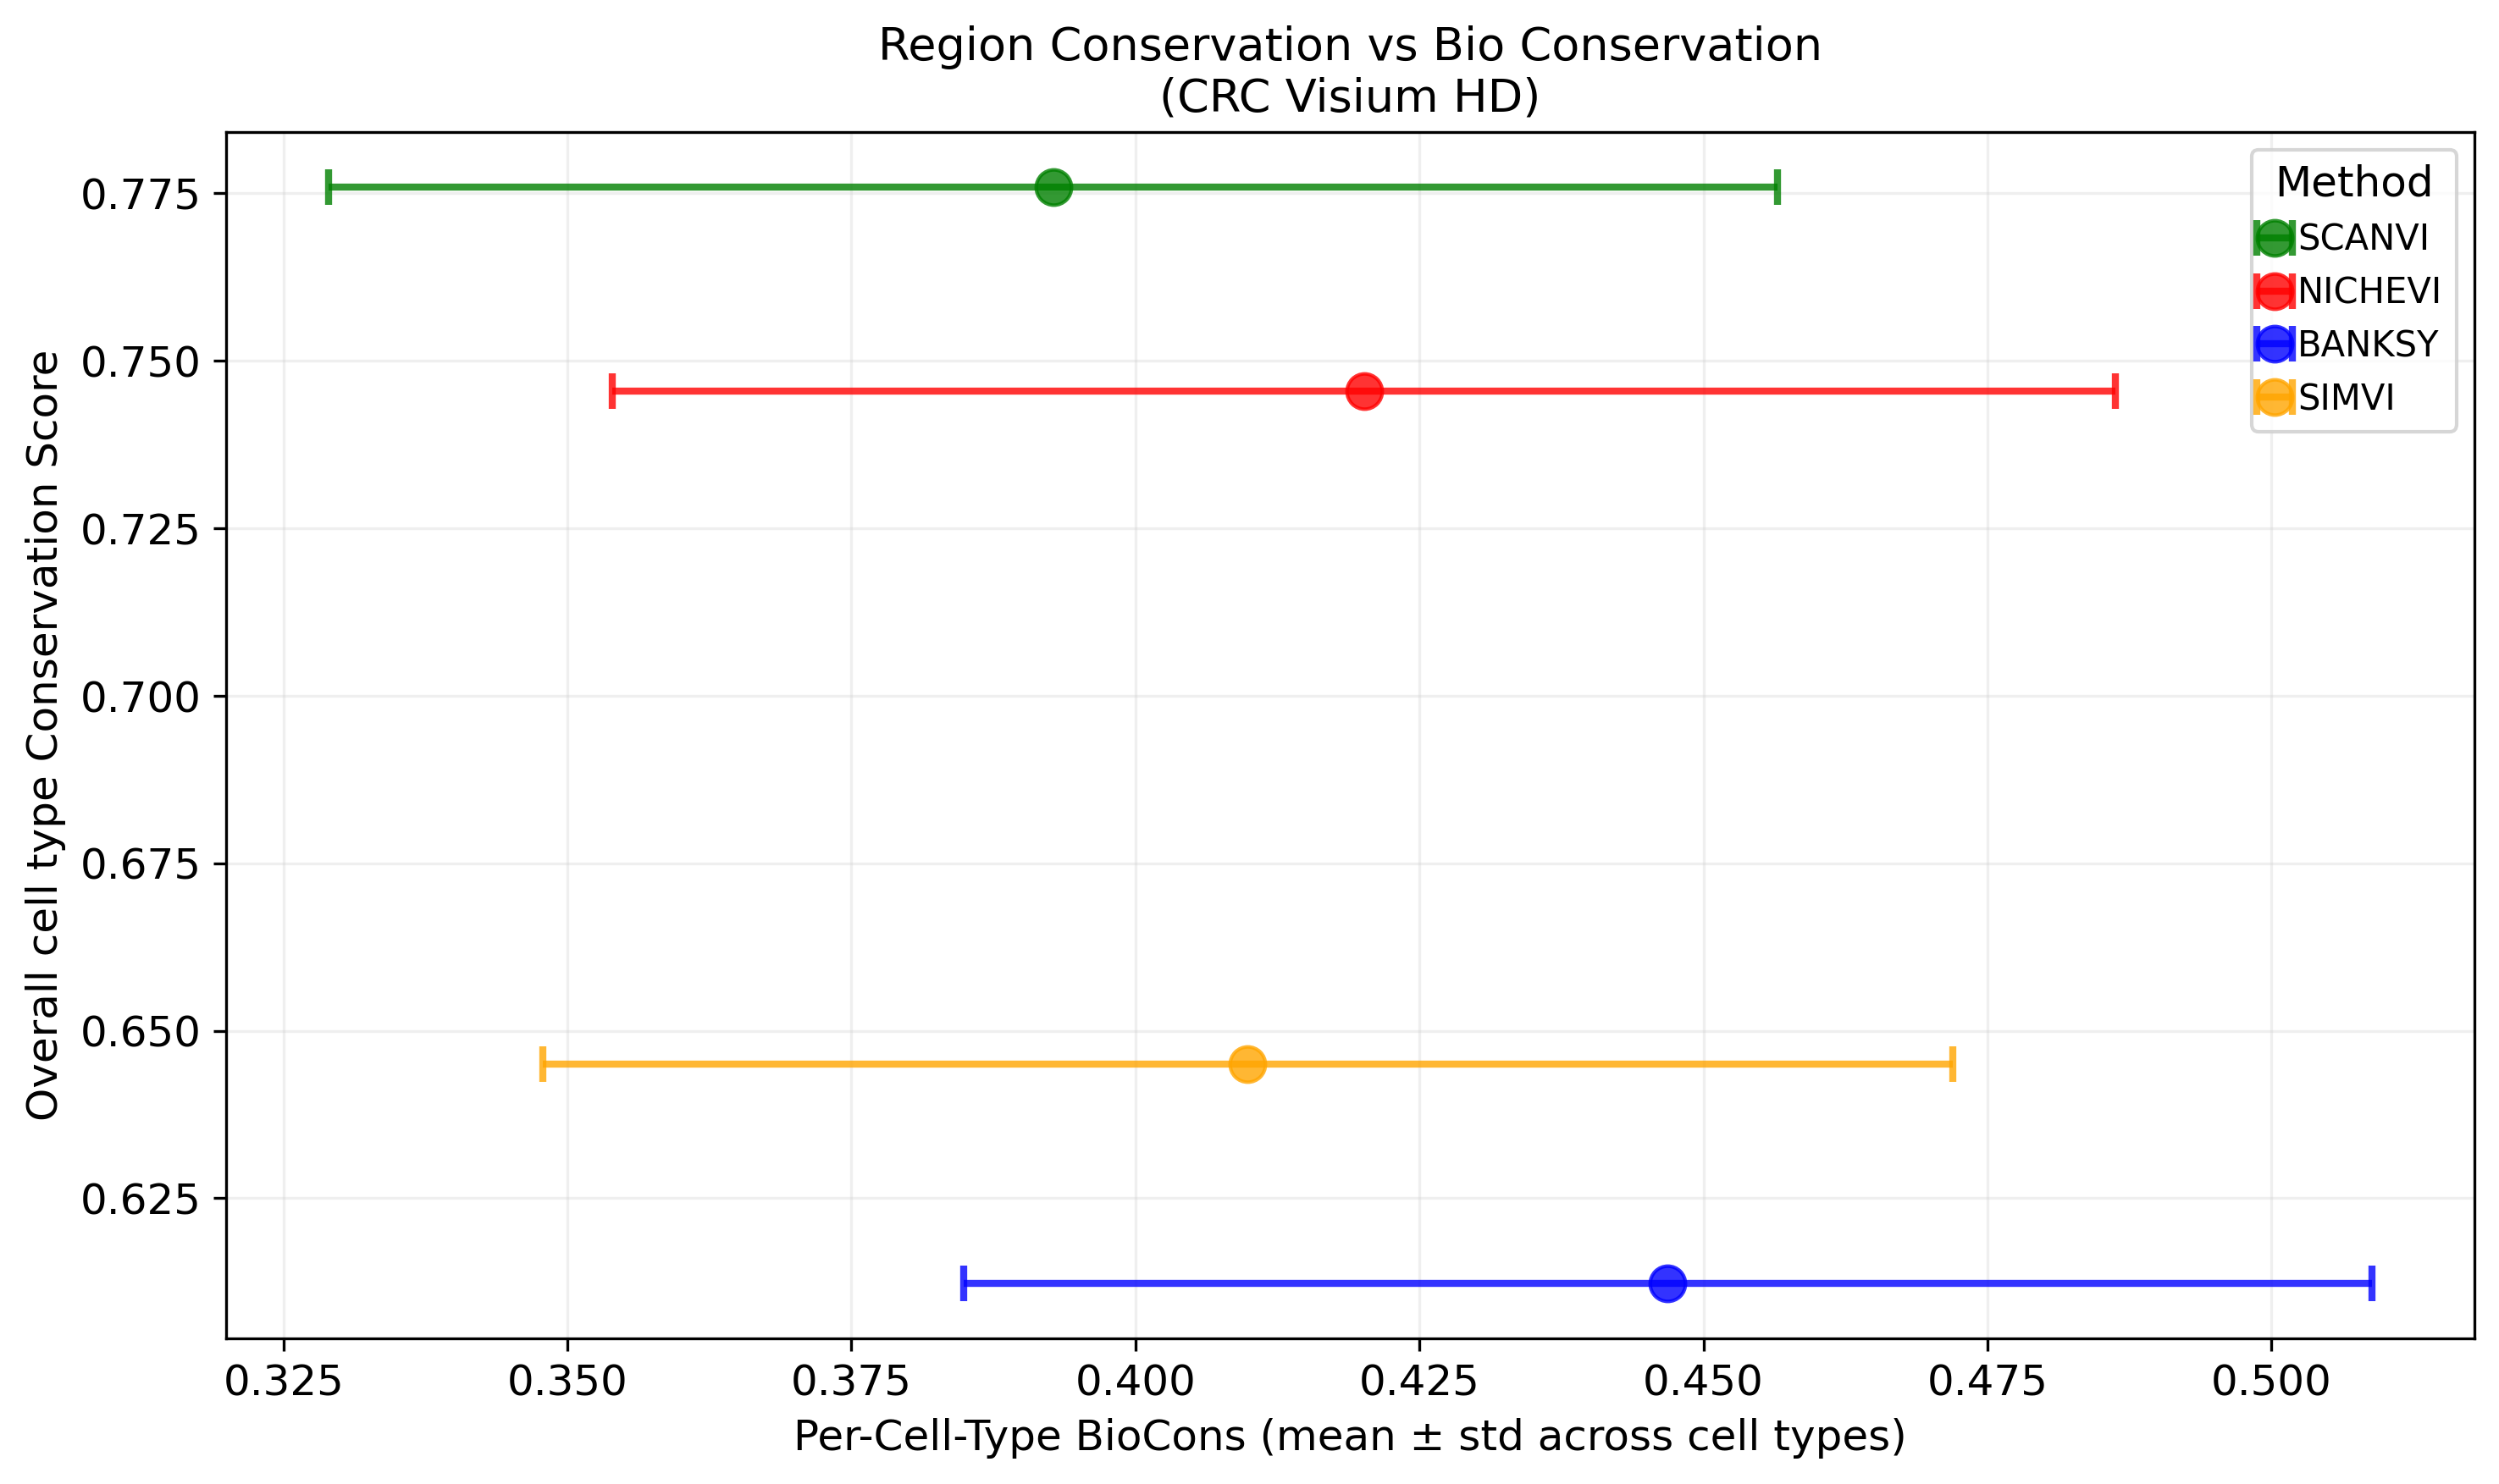

In [10]:
# Load data
df_per_cell_type = pd.read_csv(path_to_save_scib + "/BioCons_cell_type_adata_legacy_hvg4k.csv", index_col=0)

df_overall = pd.read_csv(path_to_save_scib + "/scib_cell_type_results_adata_legacy_hvg4k.csv", index_col=0)

# Remove the "Metric Type" row from overall scores
df_overall = df_overall[df_overall.index != "Metric Type"]

# Rename methods for consistency
rename_dict = {
    "X_scanvi": "SCANVI",
    "ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI": "NICHEVI",
    "simvi25_both_mae_50": "SIMVI",
    "banksy_pc_20_lambda_0.2": "BANKSY",
    "X_banksy_02_harmony": "BANKSY+Harmony",
}

df_per_cell_type = df_per_cell_type.rename(columns=rename_dict)
df_overall = df_overall.rename(index=rename_dict)

# Remove BANKSY (without Harmony) from both dataframes
df_per_cell_type = df_per_cell_type.drop(columns=["BANKSY+Harmony"], errors="ignore")
df_overall = df_overall.drop(index=["BANKSY+Harmony"], errors="ignore")


# Compute X-axis: mean and std of per-cell-type cLISI scores
x_mean = df_per_cell_type.mean(axis=0)  # Mean across cell types
x_std = df_per_cell_type.std(axis=0)  # Std across cell types

# Extract Y-axis: overall bio conservation score
y = df_overall["Bio conservation"].astype(float)

# Align methods between both dataframes
common_methods = x_mean.index.intersection(y.index)

print(f"Common methods: {common_methods.tolist()}")
print(f"\nX-axis (per-cell-type cLISI):")
print(pd.DataFrame({"mean": x_mean[common_methods], "std": x_std[common_methods]}).round(4))
print(f"\nY-axis (overall bio conservation):")
print(y[common_methods].round(4))

# Define custom colors
custom_colors = {
    "NICHEVI": "red",
    "SCANVI": "green",
    "BANKSY": "blue",
    "BANKSY+Harmony": "dodgerblue",
    "SIMVI": "orange",
}

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

for method in common_methods:
    color = custom_colors.get(method, "gray")

    # Plot point with horizontal error bar
    ax.errorbar(
        x_mean[method],
        y[method],
        xerr=x_std[method],  # Horizontal error bars for std across cell types
        fmt="o",
        color=color,
        label=method,
        markersize=10,
        capsize=5,
        capthick=2,
        elinewidth=2,
        alpha=0.8,
    )

# Labels and formatting
ax.set_xlabel("Per-Cell-Type BioCons (mean ± std across cell types)", fontsize=12)
ax.set_ylabel("Overall cell type Conservation Score", fontsize=12)
ax.set_title("Region Conservation vs Bio Conservation\n(CRC Visium HD)", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(title="Method", loc="best", fontsize=10)

plt.tight_layout()
figures_folder = setup.FIGURES_FOLDER
# Save
plt.savefig(f"{figures_folder}/region_conservation_biocons_scatter.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{figures_folder}/region_conservation_biocons_scatter.svg", bbox_inches="tight")
plt.show()